# CTDS-JAX Performance Benchmark Suite

This notebook benchmarks the JAX implementation of the Cell-Type Dynamical System (CTDS) EM algorithm across 8 test categories:

1. **JIT Compilation & Warmup** — one-time compile cost vs steady-state speed
2. **EM Iteration Speed Scaling** — wall time vs T, N, D, B
3. **Full EM Convergence** — log-likelihood curves across seeds and problem sizes
4. **vmap Batch Efficiency** — vmap vs Python for-loop over batch dim
5. **Component Profiling** — relative time of e_step vs m_step
6. **Parameter Recovery Accuracy vs Speed** — quality tradeoff with EM iterations
7. **Memory Scaling** — peak RAM as a function of B, T, N, D
8. **Large-Scale Stress Test** — realistic neuroscience-scale run

## 0. Imports & Setup

In [1]:
import sys
import os
import time
import tracemalloc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
from functools import partial

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- adjust this path to point to your CTDS source directory ---
#sys.path.insert(0, '../')   

from models import CTDS
from simulation_utilis import generate_synthetic_data, generate_CTDS_Params
from params import ParamsCTDS

jax.config.update('jax_enable_x64', True)

print(f'JAX version : {jax.__version__}')
print(f'JAX backend : {jax.default_backend()}')
print(f'Devices     : {jax.devices()}')
print(f'Python Enviroment: {sys.executable}')
# ── Plotting style ──────────────────────────────────────────────
PALETTE   = sns.color_palette('colorblind')
FIG_W     = 14   # default figure width
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({'axes.titlesize': 13, 'axes.labelsize': 12})

JAX version : 0.4.38
JAX backend : cpu
Devices     : [CpuDevice(id=0)]
Python Enviroment: /usr/local/bin/python3


## Helper utilities

In [2]:
# ── Timing helpers ───────────────────────────────────────────────
def time_fn(fn, *args, n_repeats: int = 5, warmup: bool = True):
    """Time a function (with JAX block_until_ready), optionally after a warmup call.
    Returns (mean_s, std_s, first_call_s)."""
    if warmup:
        # First call triggers JIT compilation
        t0 = time.perf_counter()
        out = fn(*args)
        jax.block_until_ready(out)
        first_call = time.perf_counter() - t0
    else:
        first_call = None

    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        out = fn(*args)
        jax.block_until_ready(out)
        times.append(time.perf_counter() - t0)

    return float(np.mean(times)), float(np.std(times)), first_call


def make_model_and_data(N: int, T: int, D: int, B: int,
                        key: jax.random.PRNGKey = jr.PRNGKey(0)):
    """Convenience wrapper: build a CTDS model + synthetic batched observations."""
    states, obs, ctds, params = generate_synthetic_data(
        num_samples=B,
        num_timesteps=T,
        state_dim=D,
        emission_dim=N,
        cell_types=2,
        key=key,
    )  # obs: (B, T, N)
 
    batch_inputs = jnp.zeros((B, T, 1))   # placeholder; model ignores when input_weights=None


    return ctds, params, obs, states


def subspace_angle(A_true, A_est):
    """Principal angle (degrees) between column spaces of A_true and A_est."""
    Q1, _ = jnp.linalg.qr(A_true)
    Q2, _ = jnp.linalg.qr(A_est)
    sv = jnp.linalg.svd(Q1.T @ Q2, compute_uv=False)
    sv = jnp.clip(sv, -1.0, 1.0)
    return float(jnp.degrees(jnp.arccos(sv[-1])))


def frobenius_rel(A_true, A_est):
    """Relative Frobenius error ||A_est - A_true||_F / ||A_true||_F."""
    return float(jnp.linalg.norm(A_est - A_true) / (jnp.linalg.norm(A_true) + 1e-12))


print('Helpers defined.')

Helpers defined.


---
## Test 1 — JIT Compilation & Warmup
Measures the one-time compile cost of `e_step`, `m_step`, and the full `em_step`.

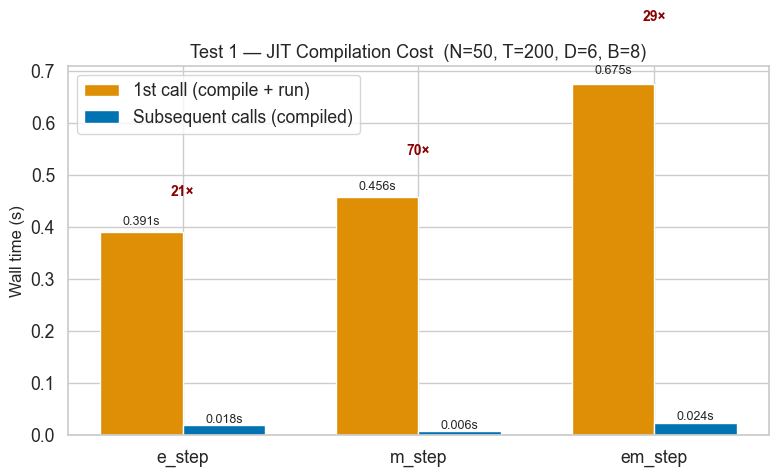

Speedups: {'e_step': '21.3x', 'm_step': '70.4x', 'em_step': '28.7x'}


In [5]:
N, T, D, B = 50, 200, 6, 8
ctds, params, obs, _ = make_model_and_data(N, T, D, B)
batch_inputs = jnp.zeros((B, T, 1))
m_step_state = ctds.initialize_m_step_state(params, num_iters=50, props=None)

# ── Helpers that expose individual steps ────────────────────────
@jax.jit
def jit_e_step(p, obs_):
    batch_stats, lls = jax.vmap(partial(ctds.e_step, p))(obs_)
    return batch_stats, lls

@partial(jax.jit, static_argnums=0)
def jit_m_step(ctds_, p, stats, state):
    return ctds_.m_step(p, None, stats, state)

@jax.jit
def jit_em_step(p, state, obs_):
    T_total = obs_.shape[0] * obs_.shape[1]
    batch_stats, lls = jax.vmap(partial(ctds.e_step, p))(obs_)
    lp = lls.sum() / T_total
    p, state = ctds.m_step(p, None, batch_stats, state)
    return p, state, lp

# ── Benchmark each component ────────────────────────────────────
components = {}

# e_step
t0 = time.perf_counter()
stats_out, lls_out = jit_e_step(params, obs)
jax.block_until_ready((stats_out, lls_out))
components['e_step'] = {'compile': time.perf_counter() - t0}
times = []
for _ in range(10):
    t0 = time.perf_counter()
    stats_out, lls_out = jit_e_step(params, obs)
    jax.block_until_ready((stats_out, lls_out))
    times.append(time.perf_counter() - t0)
components['e_step']['compiled'] = np.mean(times)

# m_step
t0 = time.perf_counter()
p_out, s_out = jit_m_step(ctds, params, stats_out, m_step_state)
jax.block_until_ready((p_out, s_out))
components['m_step'] = {'compile': time.perf_counter() - t0}
times = []
for _ in range(10):
    t0 = time.perf_counter()
    p_out2, s_out2 = jit_m_step(ctds, params, stats_out, m_step_state)
    jax.block_until_ready((p_out2, s_out2))
    times.append(time.perf_counter() - t0)
components['m_step']['compiled'] = np.mean(times)

# full em_step
t0 = time.perf_counter()
p2, s2, lp2 = jit_em_step(params, m_step_state, obs)
jax.block_until_ready((p2, s2, lp2))
components['em_step'] = {'compile': time.perf_counter() - t0}
times = []
for _ in range(10):
    t0 = time.perf_counter()
    p2, s2, lp2 = jit_em_step(params, m_step_state, obs)
    jax.block_until_ready((p2, s2, lp2))
    times.append(time.perf_counter() - t0)
components['em_step']['compiled'] = np.mean(times)

# ── Plot ─────────────────────────────────────────────────────────
labels   = list(components.keys())
compile_ = [components[k]['compile']  for k in labels]
compiled = [components[k]['compiled'] for k in labels]
x        = np.arange(len(labels))
w        = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, compile_,  w, label='1st call (compile + run)', color=PALETTE[1])
b2 = ax.bar(x + w/2, compiled,  w, label='Subsequent calls (compiled)', color=PALETTE[0])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Wall time (s)')
ax.set_title(f'Test 1 — JIT Compilation Cost  (N={N}, T={T}, D={D}, B={B})')
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h*1.02, f'{h:.3f}s',
            ha='center', va='bottom', fontsize=9)

# Speedup annotation
for i, k in enumerate(labels):
    speedup = components[k]['compile'] / components[k]['compiled']
    ax.text(i, max(compile_[i], compiled[i]) * 1.18,
            f'{speedup:.0f}×', ha='center', color='darkred', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('test1_jit_warmup.png', dpi=150, bbox_inches='tight')
plt.show()
print('Speedups:', {k: f"{components[k]['compile']/components[k]['compiled']:.1f}x" for k in labels})

---
## Test 2 — EM Iteration Speed Scaling
Wall time per compiled EM step as each axis (T, N, D, B) is swept.

In [ ]:
def bench_axis(axis: str, values, base: dict, n_repeats=5):
    """Sweep one axis of (N, T, D, B), return mean wall-times per EM step."""
    results = []
    for v in values:
        cfg = {**base, axis: v}
        N_, T_, D_, B_ = cfg['N'], cfg['T'], cfg['D'], cfg['B']
        print(f'  {axis}={v}  (N={N_}, T={T_}, D={D_}, B={B_})', end=' ... ', flush=True)
        try:
            ctds_, params_, obs_, _ = make_model_and_data(N_, T_, D_, B_, jr.PRNGKey(42))
            state_ = ctds_.initialize_m_step_state(params_, num_iters=50, props=None)

            @jax.jit
            def step(p, s):
                T_tot = obs_.shape[0] * obs_.shape[1]
                stats, lls = jax.vmap(partial(ctds_.e_step, p))(obs_)
                lp = lls.sum() / T_tot
                p, s = ctds_.m_step(p, None, stats, s)
                return p, s, lp

            # warmup
            p2, s2, lp2 = step(params_, state_)
            jax.block_until_ready((p2, s2, lp2))

            times_ = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                p2, s2, lp2 = step(p2, s2)
                jax.block_until_ready((p2, s2, lp2))
                times_.append(time.perf_counter() - t0)
            results.append((v, np.mean(times_), np.std(times_)))
            print(f'{np.mean(times_)*1000:.1f} ms')
        except Exception as e:
            print(f'FAILED: {e}')
            results.append((v, np.nan, np.nan))
    return results

BASE = dict(N=20, T=200, D=4, B=10)

T_values = [50, 100, 250, 500, 1000]
N_values = [10, 30, 50, 100, 200]
D_values = [2,  4,  6,  10,  16]
B_values = [1,  4,  8,  16,  32]

print('Sweeping T ...'); res_T = bench_axis('T', T_values, BASE)
print('Sweeping N ...'); res_N = bench_axis('N', N_values, BASE)
print('Sweeping D ...'); res_D = bench_axis('D', D_values, BASE)
print('Sweeping B ...'); res_B = bench_axis('B', B_values, BASE)

Sweeping T ...
  T=50  (N=50, T=50, D=6, B=8) ... 12.9 ms
  T=100  (N=50, T=100, D=6, B=8) ... 17.9 ms
  T=250  (N=50, T=250, D=6, B=8) ... 32.5 ms
  T=500  (N=50, T=500, D=6, B=8) ... 63.8 ms
  T=1000  (N=50, T=1000, D=6, B=8) ... 103.4 ms
Sweeping N ...
  N=10  (N=10, T=200, D=6, B=8) ... 12.8 ms
  N=30  (N=30, T=200, D=6, B=8) ... 16.7 ms
  N=50  (N=50, T=200, D=6, B=8) ... 23.3 ms
  N=100  (N=100, T=200, D=6, B=8) ... 49.9 ms
  N=200  (N=200, T=200, D=6, B=8) ... 161.9 ms
Sweeping D ...
  D=2  (N=50, T=200, D=2, B=8) ... 16.2 ms
  D=4  (N=50, T=200, D=4, B=8) ... 20.6 ms
  D=6  (N=50, T=200, D=6, B=8) ... 51.7 ms
  D=10  (N=50, T=200, D=10, B=8) ... 35.8 ms
  D=16  (N=50, T=200, D=16, B=8) ... 49.2 ms
Sweeping B ...
  B=1  (N=50, T=200, D=6, B=1) ... 21.5 ms
  B=4  (N=50, T=200, D=6, B=4) ... 21.8 ms
  B=8  (N=50, T=200, D=6, B=8) ... 27.6 ms
  B=16  (N=50, T=200, D=6, B=16) ... 25.8 ms
  B=32  (N=50, T=200, D=6, B=32) ... 43.4 ms


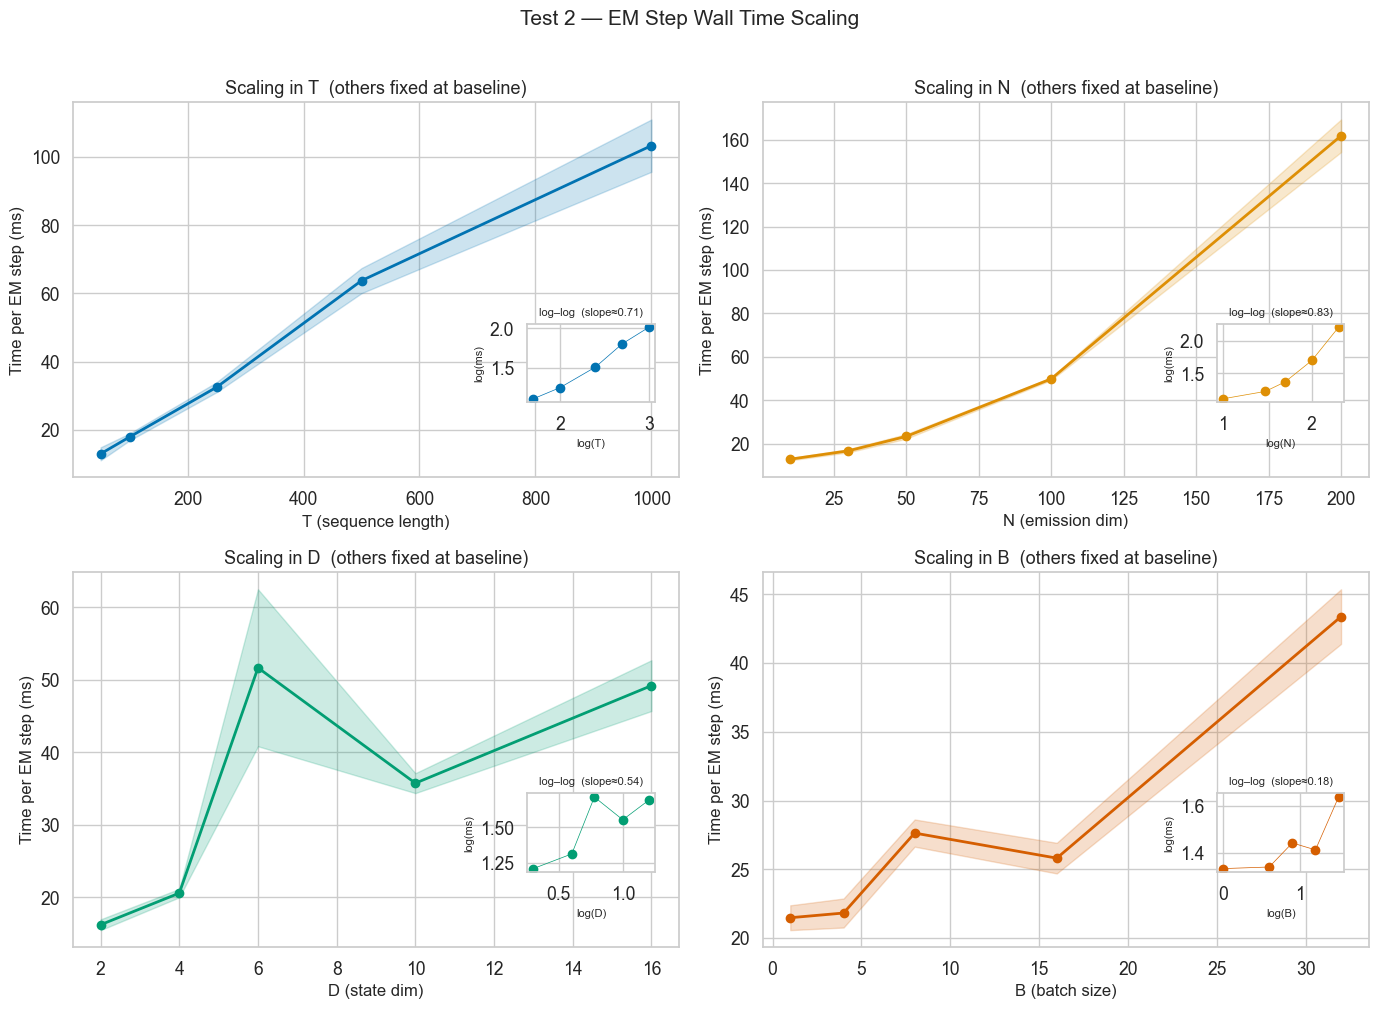

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(FIG_W, 10))
sweep_data = [
    (res_T, 'T (sequence length)',   PALETTE[0], 'T'),
    (res_N, 'N (emission dim)',       PALETTE[1], 'N'),
    (res_D, 'D (state dim)',          PALETTE[2], 'D'),
    (res_B, 'B (batch size)',         PALETTE[3], 'B'),
]

for ax, (res, xlabel, col, sym) in zip(axes.flat, sweep_data):
    xs  = np.array([r[0] for r in res])
    ys  = np.array([r[1]*1000 for r in res])   # → ms
    err = np.array([r[2]*1000 for r in res])
    valid = ~np.isnan(ys)

    # linear scale
    ax.fill_between(xs[valid], (ys-err)[valid], (ys+err)[valid], alpha=0.2, color=col)
    ax.plot(xs[valid], ys[valid], 'o-', color=col, lw=2)
    ax.set_xlabel(xlabel); ax.set_ylabel('Time per EM step (ms)')
    ax.set_title(f'Scaling in {sym}  (others fixed at baseline)')

    # inset: log-log
    #ins = ax.inset_axes([0.55, 0.08, 0.42, 0.42])
    ins = ax.inset_axes([0.75, 0.2, 0.21, 0.21])
    ins.plot(np.log10(xs[valid]), np.log10(ys[valid]), 'o-', color=col, lw=0.5)
    ins.set_xlabel(f'log({sym})', fontsize=8)
    ins.set_ylabel('log(ms)', fontsize=8)
    ins.set_title('log–log', fontsize=8)
    # fit slope
    if valid.sum() >= 2:
        slope, intercept = np.polyfit(np.log10(xs[valid]), np.log10(ys[valid]), 1)
        ins.set_title(f'log–log  (slope≈{slope:.2f})', fontsize=8)

plt.suptitle('Test 2 — EM Step Wall Time Scaling', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('test2_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Test 3 — Full EM Convergence
Log-likelihood curves across multiple random seeds, at different problem sizes.

In [29]:
N_SEEDS  = 5
N_ITERS  = 80
CONFIGS  = [
    dict(N=20,  T=100, D=4,  B=5,  label='Small  (N=30,T=100,D=4,B=5)'),
    dict(N=50,  T=200, D=6,  B=8,  label='Medium (N=50,T=200,D=6,B=8)'),
    dict(N=100, T=400, D=10, B=10, label='Large  (N=100,T=400,D=10,B=10)'),
]

convergence_results = {}  # label -> list of ll_arrays (one per seed)

for cfg in CONFIGS:
    label = cfg['label']
    print(f'Running {label} ...')
    ll_curves = []
    wall_times = []
    for seed in range(N_SEEDS):
        ctds_, params_, obs_, _ = make_model_and_data(
            cfg['N'], cfg['T'], cfg['D'], cfg['B'], jr.PRNGKey(seed * 100))
        t0 = time.perf_counter()
        _, log_probs = ctds_.fit_em(params_, obs_, batch_inputs=None, num_iters=N_ITERS)
        wall_times.append(time.perf_counter() - t0)
        # strip NaN padding from the jax.lax.while_loop version
        lp = np.array(log_probs)
        lp = lp[~np.isnan(lp)]
        ll_curves.append(lp)
        print(f'  seed {seed}: {len(lp)} iters, final LL={lp[-1]:.4f},  {wall_times[-1]:.1f}s')
    convergence_results[label] = {'curves': ll_curves, 'wall_times': wall_times}

Running Small  (N=30,T=100,D=4,B=5) ...
Iteration 1: ll=-8.910498714237091  rel_change=0.006168004587031846
Iteration 2: ll=-8.906289983825271  rel_change=0.0004723338779114374
Iteration 3: ll=-8.904669073795604  rel_change=0.0001819960985561474
Iteration 4: ll=-8.9034895148711  rel_change=0.000132465217374017
Iteration 5: ll=-8.902438893957203  rel_change=0.00011800102781524517
Iteration 6: ll=-8.901479635660174  rel_change=0.00010775230343693771
Iteration 7: ll=-8.900625350955607  rel_change=9.597109014807403e-05
Iteration 8: ll=-8.89990442081981  rel_change=8.099769481025306e-05
Iteration 9: ll=-8.89928338211752  rel_change=6.978037885850579e-05
Iteration 10: ll=-8.898741174895946  rel_change=6.092706550551653e-05
Iteration 11: ll=-8.898263370744498  rel_change=5.369345417027184e-05
Iteration 12: ll=-8.89783942029002  rel_change=4.7644179185794755e-05
Iteration 13: ll=-8.89746134332734  rel_change=4.249087276396614e-05
Iteration 14: ll=-8.897122826773332  rel_change=3.80464203153962

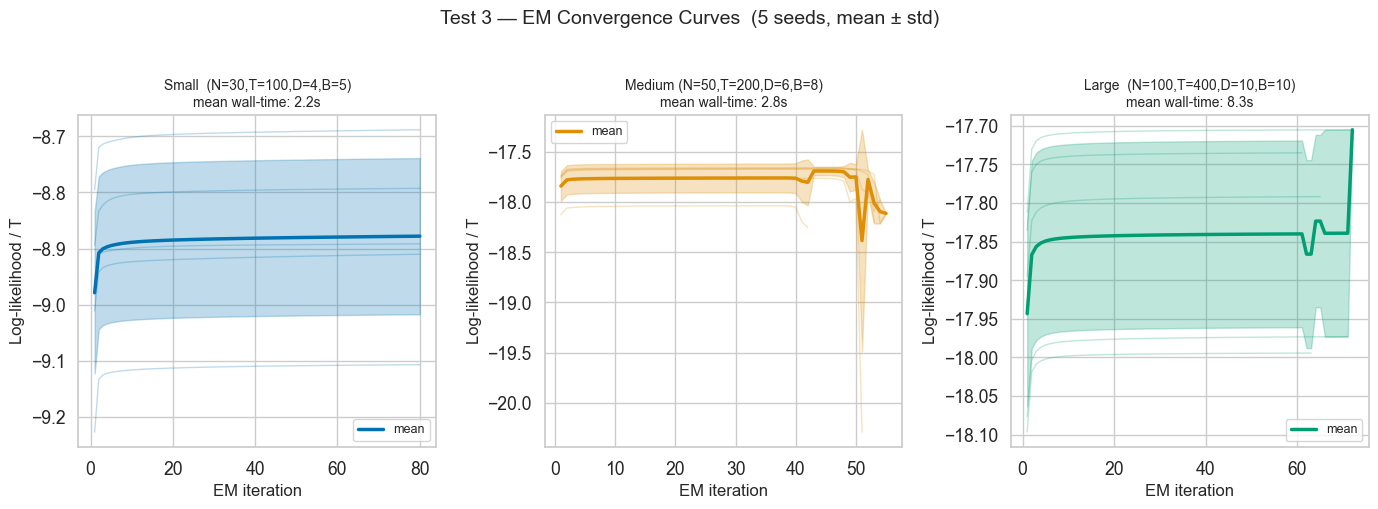

In [30]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(FIG_W, 5), sharey=False)

for ax, (label, data), col in zip(axes, convergence_results.items(), PALETTE):
    curves = data['curves']
    # pad to same length for mean/std
    max_len = max(len(c) for c in curves)
    padded  = np.full((len(curves), max_len), np.nan)
    for i, c in enumerate(curves):
        padded[i, :len(c)] = c

    mean_ll = np.nanmean(padded, axis=0)
    std_ll  = np.nanstd(padded,  axis=0)
    iters   = np.arange(1, max_len + 1)

    # individual seed traces
    for c in curves:
        ax.plot(np.arange(1, len(c)+1), c, alpha=0.25, lw=1, color=col)
    # mean ± std band
    ax.fill_between(iters, mean_ll - std_ll, mean_ll + std_ll, alpha=0.25, color=col)
    ax.plot(iters, mean_ll, lw=2.5, color=col, label='mean')

    mean_wall = np.mean(data['wall_times'])
    ax.set_xlabel('EM iteration')
    ax.set_ylabel('Log-likelihood / T')
    ax.set_title(f'{label}\nmean wall-time: {mean_wall:.1f}s', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Test 3 — EM Convergence Curves  (5 seeds, mean ± std)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('test3_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Test 4 — vmap Batch Efficiency
Compares `jax.vmap(e_step)` over the batch dimension against a sequential Python for-loop.

In [32]:
N_BENCH, T_BENCH, D_BENCH = 20, 200, 4
B_VALUES = [1, 2, 4, 8, 16, 24, 32]
N_REPS   = 5

vmap_times  = []
loop_times  = []

for B_ in B_VALUES:
    ctds_, params_, obs_, _ = make_model_and_data(N_BENCH, T_BENCH, D_BENCH, B_, jr.PRNGKey(0))
    inp_ = jnp.zeros((B_, T_BENCH, 1))

    # ── vmap version ────────────────────────────────────────────
    @jax.jit
    def vmap_estep(p):
        return jax.vmap(partial(ctds_.e_step, p))(obs_, inp_)

    # warmup
    out = vmap_estep(params_); jax.block_until_ready(out)
    ts = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        out = vmap_estep(params_); jax.block_until_ready(out)
        ts.append(time.perf_counter() - t0)
    vmap_times.append((np.mean(ts), np.std(ts)))

    # ── sequential for-loop version ─────────────────────────────
    @jax.jit
    def single_estep(p, y, i):
        return ctds_.e_step(p, y, i)

    # warmup
    single_estep(params_, obs_[0], inp_[0]); 
    jax.block_until_ready(single_estep(params_, obs_[0], inp_[0]))

    ts = []
    for _ in range(N_REPS):
        t0 = time.perf_counter()
        results = []
        for b in range(B_):
            r = single_estep(params_, obs_[b], inp_[b])
            results.append(r)
        jax.block_until_ready(results)
        ts.append(time.perf_counter() - t0)
    loop_times.append((np.mean(ts), np.std(ts)))

    print(f'B={B_:2d}  vmap={vmap_times[-1][0]*1000:.1f}ms  loop={loop_times[-1][0]*1000:.1f}ms  '
          f'speedup={loop_times[-1][0]/vmap_times[-1][0]:.1f}x')

B= 1  vmap=6.6ms  loop=7.1ms  speedup=1.1x
B= 2  vmap=10.4ms  loop=15.8ms  speedup=1.5x
B= 4  vmap=8.1ms  loop=27.7ms  speedup=3.4x
B= 8  vmap=8.5ms  loop=55.0ms  speedup=6.5x
B=16  vmap=10.0ms  loop=107.9ms  speedup=10.8x
B=24  vmap=13.7ms  loop=159.2ms  speedup=11.6x
B=32  vmap=15.8ms  loop=214.9ms  speedup=13.6x


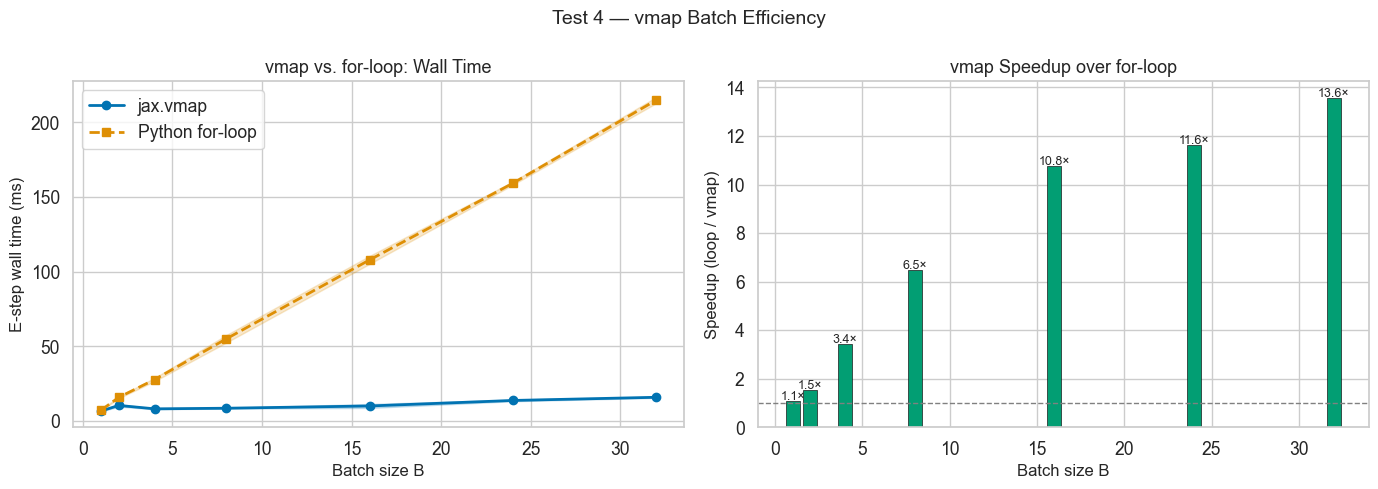

In [33]:
vmap_m = np.array([x[0]*1000 for x in vmap_times])
vmap_s = np.array([x[1]*1000 for x in vmap_times])
loop_m = np.array([x[0]*1000 for x in loop_times])
loop_s = np.array([x[1]*1000 for x in loop_times])
speedups = loop_m / vmap_m

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Wall time comparison
ax1.fill_between(B_VALUES, vmap_m - vmap_s, vmap_m + vmap_s, alpha=0.2, color=PALETTE[0])
ax1.fill_between(B_VALUES, loop_m - loop_s, loop_m + loop_s, alpha=0.2, color=PALETTE[1])
ax1.plot(B_VALUES, vmap_m, 'o-', color=PALETTE[0], lw=2, label='jax.vmap')
ax1.plot(B_VALUES, loop_m, 's--', color=PALETTE[1], lw=2, label='Python for-loop')
ax1.set_xlabel('Batch size B')
ax1.set_ylabel('E-step wall time (ms)')
ax1.set_title('vmap vs. for-loop: Wall Time')
ax1.legend()

# Speedup
ax2.bar(B_VALUES, speedups, color=PALETTE[2], edgecolor='k', linewidth=0.5)
ax2.axhline(1.0, color='grey', lw=1, linestyle='--')
ax2.set_xlabel('Batch size B')
ax2.set_ylabel('Speedup (loop / vmap)')
ax2.set_title('vmap Speedup over for-loop')
for i, (b, s) in enumerate(zip(B_VALUES, speedups)):
    ax2.text(b, s + 0.05, f'{s:.1f}×', ha='center', fontsize=9)

plt.suptitle('Test 4 — vmap Batch Efficiency', fontsize=14)
plt.tight_layout()
plt.savefig('test4_vmap_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Test 5 — Component Profiling: e_step vs m_step
Shows what fraction of each EM iteration is spent in each component across problem sizes.

In [36]:
PROFILE_CONFIGS = [
    dict(N=30,  T=100, D=4,  B=4,  label='Small'),
    dict(N=50,  T=200, D=6,  B=8,  label='Medium'),
    dict(N=100, T=300, D=10, B=10, label='Large'),
]
N_REPS_PROF = 8

profile_results = []

for cfg in PROFILE_CONFIGS:
    N_, T_, D_, B_ = cfg['N'], cfg['T'], cfg['D'], cfg['B']
    ctds_, params_, obs_, _ = make_model_and_data(N_, T_, D_, B_, jr.PRNGKey(1))
    inp_   = jnp.zeros((B_, T_, 1))
    state_ = ctds_.initialize_m_step_state(params_, num_iters=50, props=None)

    @jax.jit
    def e_only(p):
        return jax.vmap(partial(ctds_.e_step, p))(obs_)

    @partial(jax.jit, static_argnums=0)
    def m_only(ctds__, p, stats, m_state):
        return ctds__.m_step(p, None, stats, m_step_state=m_state)

    # warmup
    stats_out, l_out = e_only(params_); jax.block_until_ready((s_out, l_out))
    p_out, st_out = m_only(ctds_, params_, stats_out, state_); jax.block_until_ready((p_out, st_out))

    # time e_step
    ts = []
    for _ in range(N_REPS_PROF):
        t0 = time.perf_counter()
        s_out, l_out = e_only(params_); jax.block_until_ready((s_out, l_out))
        ts.append(time.perf_counter() - t0)
    e_time = np.mean(ts) * 1000

    # time m_step
    ts = []
    for _ in range(N_REPS_PROF):
        t0 = time.perf_counter()
        p_out, st_out = m_only(ctds_, params_, s_out, state_); jax.block_until_ready((p_out, st_out))
        ts.append(time.perf_counter() - t0)
    m_time = np.mean(ts) * 1000

    profile_results.append({'label': cfg['label'], 'e_step': e_time, 'm_step': m_time})
    print(f"{cfg['label']}: e_step={e_time:.1f}ms  m_step={m_time:.1f}ms  "
          f"ratio={e_time/(m_time+1e-9):.1f}")

Small: e_step=4.8ms  m_step=2.0ms  ratio=2.3
Medium: e_step=20.2ms  m_step=6.7ms  ratio=3.0
Large: e_step=75.3ms  m_step=12.6ms  ratio=6.0


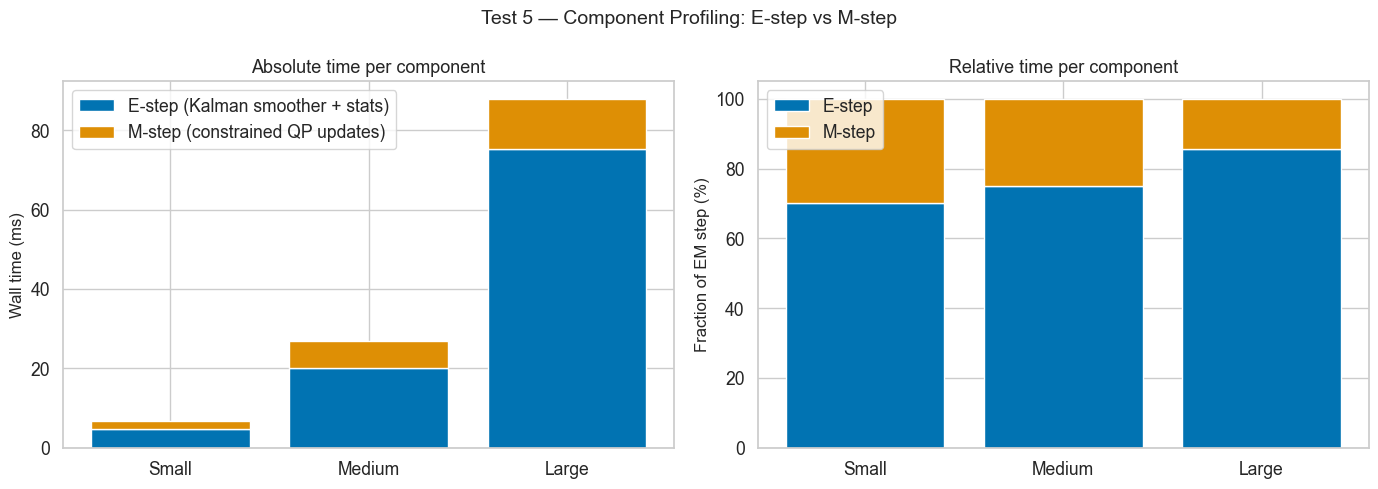

In [37]:
labels_p  = [r['label']  for r in profile_results]
e_times   = np.array([r['e_step'] for r in profile_results])
m_times   = np.array([r['m_step'] for r in profile_results])
totals    = e_times + m_times

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Stacked bar — absolute
x = np.arange(len(labels_p))
ax1.bar(x, e_times, label='E-step (Kalman smoother + stats)', color=PALETTE[0])
ax1.bar(x, m_times, bottom=e_times, label='M-step (constrained QP updates)', color=PALETTE[1])
ax1.set_xticks(x); ax1.set_xticklabels(labels_p)
ax1.set_ylabel('Wall time (ms)')
ax1.set_title('Absolute time per component')
ax1.legend()

# Stacked bar — fractional
ax2.bar(x, e_times/totals*100, label='E-step', color=PALETTE[0])
ax2.bar(x, m_times/totals*100, bottom=e_times/totals*100, label='M-step', color=PALETTE[1])
ax2.set_xticks(x); ax2.set_xticklabels(labels_p)
ax2.set_ylabel('Fraction of EM step (%)')
ax2.set_title('Relative time per component')
ax2.legend()

plt.suptitle('Test 5 — Component Profiling: E-step vs M-step', fontsize=14)
plt.tight_layout()
plt.savefig('test5_component_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Test 6 — Parameter Recovery Accuracy vs. Speed
Tracks how fast parameters converge to ground truth (Frobenius error in A and subspace angle in C) as a function of wall time.

In [41]:
N_REC, T_REC, D_REC, B_REC = 50, 200, 6, 8
N_ITERS_REC = 100
N_SEEDS_REC = 3

rec_results = []  # list of dicts per seed

for seed in range(N_SEEDS_REC):
    key = jr.PRNGKey(seed * 17)
    _, _, obs_r, states_r = make_model_and_data(N_REC, T_REC, D_REC, B_REC, key)

    # ground truth params
    _, true_params, _, _ = make_model_and_data(N_REC, T_REC, D_REC, B_REC, key)
    A_true = np.array(true_params.dynamics.weights)
    C_true = np.array(true_params.emissions.weights)

    # fresh init from a *different* key so we're not starting at truth
    ctds_r, init_params, obs_r, _ = make_model_and_data(N_REC, T_REC, D_REC, B_REC, jr.PRNGKey(seed * 17 + 999))
    inp_r = jnp.zeros((B_REC, T_REC, 1))

    state_r  = ctds_r.initialize_m_step_state(init_params, num_iters=N_ITERS_REC, props=None)

    @jax.jit
    def em_step_r(p, s):
        T_tot = obs_r.shape[0] * obs_r.shape[1]
        stats, lls = jax.vmap(partial(ctds_r.e_step, p))(obs_r)
        lp = lls.sum() / T_tot
        p, s = ctds_r.m_step(p, None, stats, s)
        return p, s, lp

    # warmup
    p_r, s_r, lp_r = em_step_r(init_params, state_r)
    jax.block_until_ready((p_r, s_r, lp_r))

    A_errs, C_angles, lls_r, cum_times = [], [], [], []
    p_r, s_r = init_params, state_r
    t_start = time.perf_counter()

    for i in range(N_ITERS_REC):
        t0 = time.perf_counter()
        p_r, s_r, lp_r = em_step_r(p_r, s_r)
        jax.block_until_ready((p_r, s_r, lp_r))
        cum_times.append(time.perf_counter() - t_start)

        A_est = np.array(p_r.dynamics.weights)
        C_est = np.array(p_r.emissions.weights)
        A_errs.append(frobenius_rel(A_true, A_est))
        C_angles.append(subspace_angle(C_true, C_est))
        lls_r.append(float(lp_r))

    rec_results.append({'A_errs': A_errs, 'C_angles': C_angles,
                        'lls': lls_r, 'times': cum_times})
    print(f'Seed {seed}: final A_err={A_errs[-1]:.3f}  C_angle={C_angles[-1]:.1f}°  LL={lls_r[-1]:.4f}')

Seed 0: final A_err=nan  C_angle=nan°  LL=nan
Seed 1: final A_err=nan  C_angle=nan°  LL=nan
Seed 2: final A_err=nan  C_angle=nan°  LL=nan


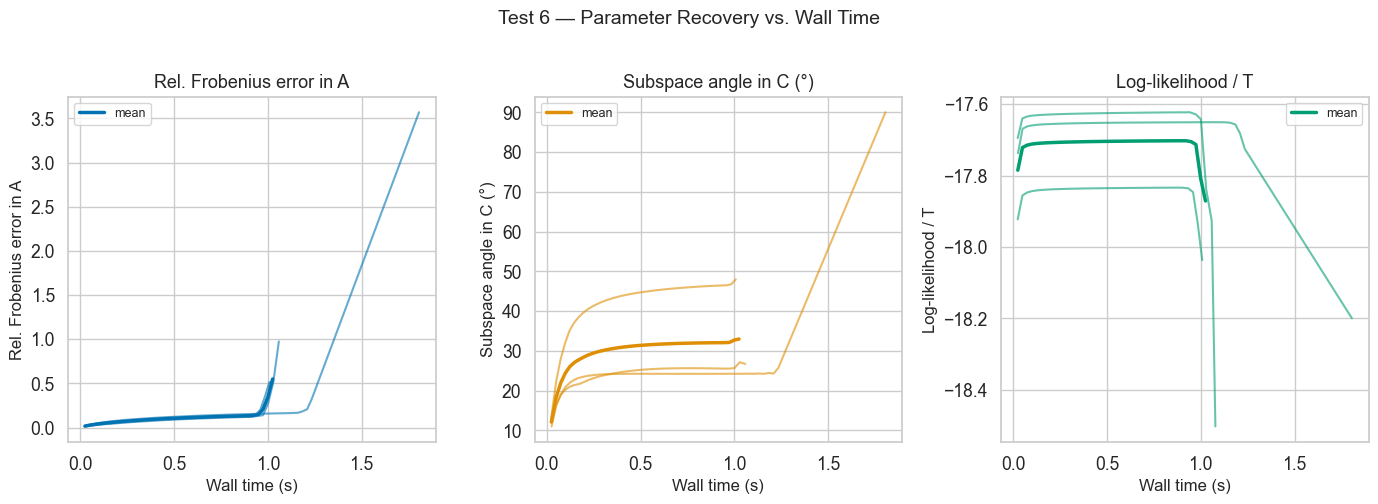

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, 5))

metrics = [
    ('A_errs',   'Rel. Frobenius error in A',  PALETTE[0]),
    ('C_angles', 'Subspace angle in C (°)',     PALETTE[1]),
    ('lls',      'Log-likelihood / T',          PALETTE[2]),
]

for ax, (key_, ylabel, col) in zip(axes, metrics):
    for res in rec_results:
        ax.plot(res['times'], res[key_], alpha=0.6, lw=1.5, color=col)
    # mean
    min_len = min(len(r[key_]) for r in rec_results)
    arr = np.array([r[key_][:min_len] for r in rec_results])
    t_arr = np.array([r['times'][:min_len] for r in rec_results])
    ax.plot(t_arr.mean(0), arr.mean(0), lw=2.5, color=col, label='mean')
    ax.set_xlabel('Wall time (s)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)

plt.suptitle('Test 6 — Parameter Recovery vs. Wall Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('test6_recovery.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Test 7 — Memory Scaling
Peak RAM consumption (via `tracemalloc`) as a function of T, D, B, N.

In [43]:
def measure_memory_mb(N_, T_, D_, B_):
    """Run one EM step and return peak tracemalloc memory in MB."""
    import gc; gc.collect()
    tracemalloc.start()
    try:
        ctds_, params_, obs_, _ = make_model_and_data(N_, T_, D_, B_, jr.PRNGKey(42))
        inp_ = None
        state_ = ctds_.initialize_m_step_state(params_, num_iters=10, props=None)

        @jax.jit
        def step(p, s):
            T_tot = obs_.shape[0] * obs_.shape[1]
            stats, lls = jax.vmap(partial(ctds_.e_step, p))(obs_,inp_ )
            lp = lls.sum() / T_tot
            p, s = ctds_.m_step(p, None, stats, s)
            return p, s, lp

        p2, s2, lp2 = step(params_, state_)
        jax.block_until_ready((p2, s2, lp2))
        _, peak = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()
    return peak / 1024**2  # bytes → MB

# Build 2D grids
T_grid = [50, 100, 200, 400]
D_grid = [2,   4,   8,  12]
B_grid = [2,   4,   8,  16]
N_grid = [20,  50, 100, 200]

BASE_MEM = dict(N=50, T=200, D=6, B=8)

# TD heatmap
print('Building T×D memory heatmap ...')
TD_mem = np.zeros((len(T_grid), len(D_grid)))
for i, T_ in enumerate(T_grid):
    for j, D_ in enumerate(D_grid):
        TD_mem[i, j] = measure_memory_mb(BASE_MEM['N'], T_, D_, BASE_MEM['B'])
        print(f'  T={T_}, D={D_}:  {TD_mem[i,j]:.1f} MB')

# BN heatmap
print('Building B×N memory heatmap ...')
BN_mem = np.zeros((len(B_grid), len(N_grid)))
for i, B_ in enumerate(B_grid):
    for j, N_ in enumerate(N_grid):
        BN_mem[i, j] = measure_memory_mb(N_, BASE_MEM['T'], BASE_MEM['D'], B_)
        print(f'  B={B_}, N={N_}:  {BN_mem[i,j]:.1f} MB')

Building T×D memory heatmap ...
  T=50, D=2:  3.0 MB
  T=50, D=4:  2.6 MB
  T=50, D=8:  7.3 MB
  T=50, D=12:  7.2 MB
  T=100, D=2:  2.8 MB
  T=100, D=4:  2.8 MB
  T=100, D=8:  2.9 MB
  T=100, D=12:  2.8 MB
  T=200, D=2:  3.3 MB
  T=200, D=4:  3.3 MB
  T=200, D=8:  3.4 MB
  T=200, D=12:  3.4 MB
  T=400, D=2:  4.9 MB
  T=400, D=4:  4.7 MB
  T=400, D=8:  4.7 MB
  T=400, D=12:  4.7 MB
Building B×N memory heatmap ...
  B=2, N=20:  3.7 MB
  B=2, N=50:  2.5 MB
  B=2, N=100:  3.6 MB
  B=2, N=200:  4.3 MB
  B=4, N=20:  2.6 MB
  B=4, N=50:  2.8 MB
  B=4, N=100:  4.1 MB
  B=4, N=200:  5.3 MB
  B=8, N=20:  2.8 MB
  B=8, N=50:  3.3 MB
  B=8, N=100:  4.7 MB
  B=8, N=200:  7.1 MB
  B=16, N=20:  3.3 MB
  B=16, N=50:  4.6 MB
  B=16, N=100:  7.8 MB
  B=16, N=200:  12.7 MB


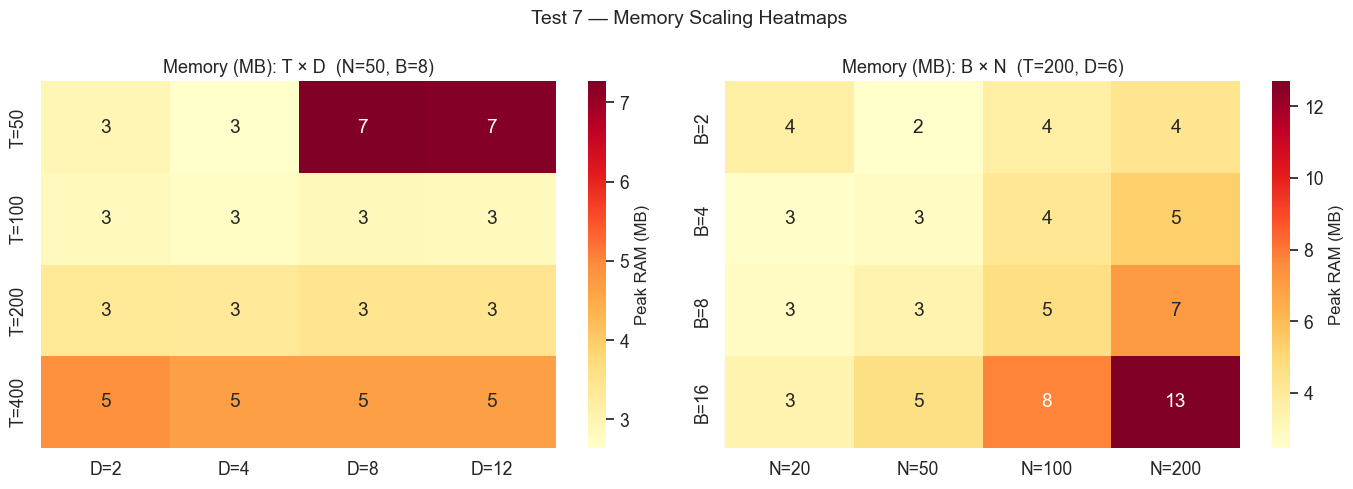

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, 5))

sns.heatmap(TD_mem, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=[f'D={d}' for d in D_grid],
            yticklabels=[f'T={t}' for t in T_grid],
            ax=ax1, cbar_kws={'label': 'Peak RAM (MB)'})
ax1.set_title(f'Memory (MB): T × D  (N={BASE_MEM["N"]}, B={BASE_MEM["B"]})')

sns.heatmap(BN_mem, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=[f'N={n}' for n in N_grid],
            yticklabels=[f'B={b}' for b in B_grid],
            ax=ax2, cbar_kws={'label': 'Peak RAM (MB)'})
ax2.set_title(f'Memory (MB): B × N  (T={BASE_MEM["T"]}, D={BASE_MEM["D"]})')

plt.suptitle('Test 7 — Memory Scaling Heatmaps', fontsize=14)
plt.tight_layout()
plt.savefig('test7_memory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Test 8 — Large-Scale Stress Test
Realistic neuroscience-scale run: N=200 neurons, T=500 timesteps, D=10 latents, B=20 trials.

In [45]:
N_STRESS, T_STRESS, D_STRESS, B_STRESS = 200, 500, 10, 20
N_ITERS_STRESS = 60

print(f'Stress test: N={N_STRESS}, T={T_STRESS}, D={D_STRESS}, B={B_STRESS}')
print(f'Estimated data size: {N_STRESS*T_STRESS*B_STRESS*8/1024**2:.1f} MB  (float64)')

ctds_s, params_s, obs_s, _ = make_model_and_data(N_STRESS, T_STRESS, D_STRESS, B_STRESS, jr.PRNGKey(7))

t_stress_start = time.perf_counter()
_, lp_stress = ctds_s.fit_em(params_s, obs_s, batch_inputs=None, num_iters=N_ITERS_STRESS)
t_stress_total = time.perf_counter() - t_stress_start

lp_stress_clean = np.array(lp_stress)
lp_stress_clean = lp_stress_clean[~np.isnan(lp_stress_clean)]

n_iters_ran = len(lp_stress_clean)
print(f'\n=== Stress test summary ===')
print(f'  Iterations run      : {n_iters_ran}')
print(f'  Total wall time     : {t_stress_total:.1f}s')
print(f'  Avg per EM step     : {t_stress_total/n_iters_ran*1000:.1f} ms')
print(f'  Initial LL          : {lp_stress_clean[0]:.4f}')
print(f'  Final LL            : {lp_stress_clean[-1]:.4f}')
print(f'  LL gain             : {lp_stress_clean[-1] - lp_stress_clean[0]:.4f}')
nan_count = np.sum(np.isnan(np.array(lp_stress)))
print(f'  NaN LL values       : {nan_count}  (should be 0 if converged cleanly)')

Stress test: N=200, T=500, D=10, B=20
Estimated data size: 15.3 MB  (float64)
Iteration 1: ll=-38.54967905370207  rel_change=0.0015428581337631085
Iteration 2: ll=-38.544053287443546  rel_change=0.00014593548887114412
Iteration 3: ll=-38.542197218143286  rel_change=4.815449185949454e-05
Iteration 4: ll=-38.541395306739666  rel_change=2.080606352255195e-05
Iteration 5: ll=-38.54096263003467  rel_change=1.1226285440678822e-05
Iteration 6: ll=-38.54069072027736  rel_change=7.0550847397699735e-06
Iteration 7: ll=-38.54049906658647  rel_change=4.972762223791529e-06
Iteration 8: ll=-38.540353588310545  rel_change=3.7746858356756193e-06
Iteration 9: ll=-38.5402376458052  rel_change=3.0083404678922277e-06
Iteration 10: ll=-38.5401420782059  rel_change=2.4796837054569707e-06
Iteration 11: ll=-38.54006134659512  rel_change=2.094740871121519e-06
Iteration 12: ll=-38.53999185339215  rel_change=1.8031419913072888e-06
Iteration 13: ll=-38.539931129684824  rel_change=1.575602495148805e-06
Iteration 1

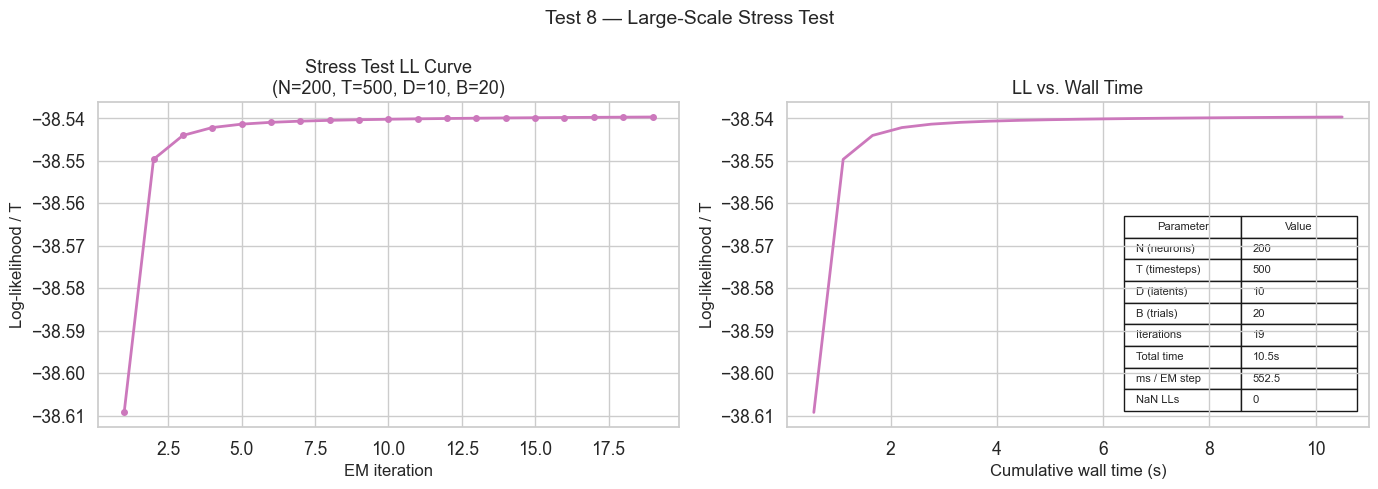

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# LL curve
ax = axes[0]
ax.plot(np.arange(1, n_iters_ran+1), lp_stress_clean, 'o-', color=PALETTE[4], lw=2, ms=4)
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood / T')
ax.set_title(f'Stress Test LL Curve\n(N={N_STRESS}, T={T_STRESS}, D={D_STRESS}, B={B_STRESS})')

# Cumulative time vs LL
ax2 = axes[1]
avg_step = t_stress_total / n_iters_ran
cum_t = np.arange(1, n_iters_ran+1) * avg_step
ax2.plot(cum_t, lp_stress_clean, color=PALETTE[4], lw=2)
ax2.set_xlabel('Cumulative wall time (s)')
ax2.set_ylabel('Log-likelihood / T')
ax2.set_title('LL vs. Wall Time')

# Summary table inset
table_data = [
    ['N (neurons)',      str(N_STRESS)],
    ['T (timesteps)',    str(T_STRESS)],
    ['D (latents)',      str(D_STRESS)],
    ['B (trials)',       str(B_STRESS)],
    ['Iterations',       str(n_iters_ran)],
    ['Total time',       f'{t_stress_total:.1f}s'],
    ['ms / EM step',     f'{avg_step*1000:.1f}'],
    ['NaN LLs',          str(nan_count)],
]
tbl = ax2.table(cellText=table_data, colLabels=['Parameter', 'Value'],
                bbox=[0.58, 0.05, 0.40, 0.60], cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)

plt.suptitle('Test 8 — Large-Scale Stress Test', fontsize=14)
plt.tight_layout()
plt.savefig('test8_stress.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Dashboard
One-page summary of all key metrics.

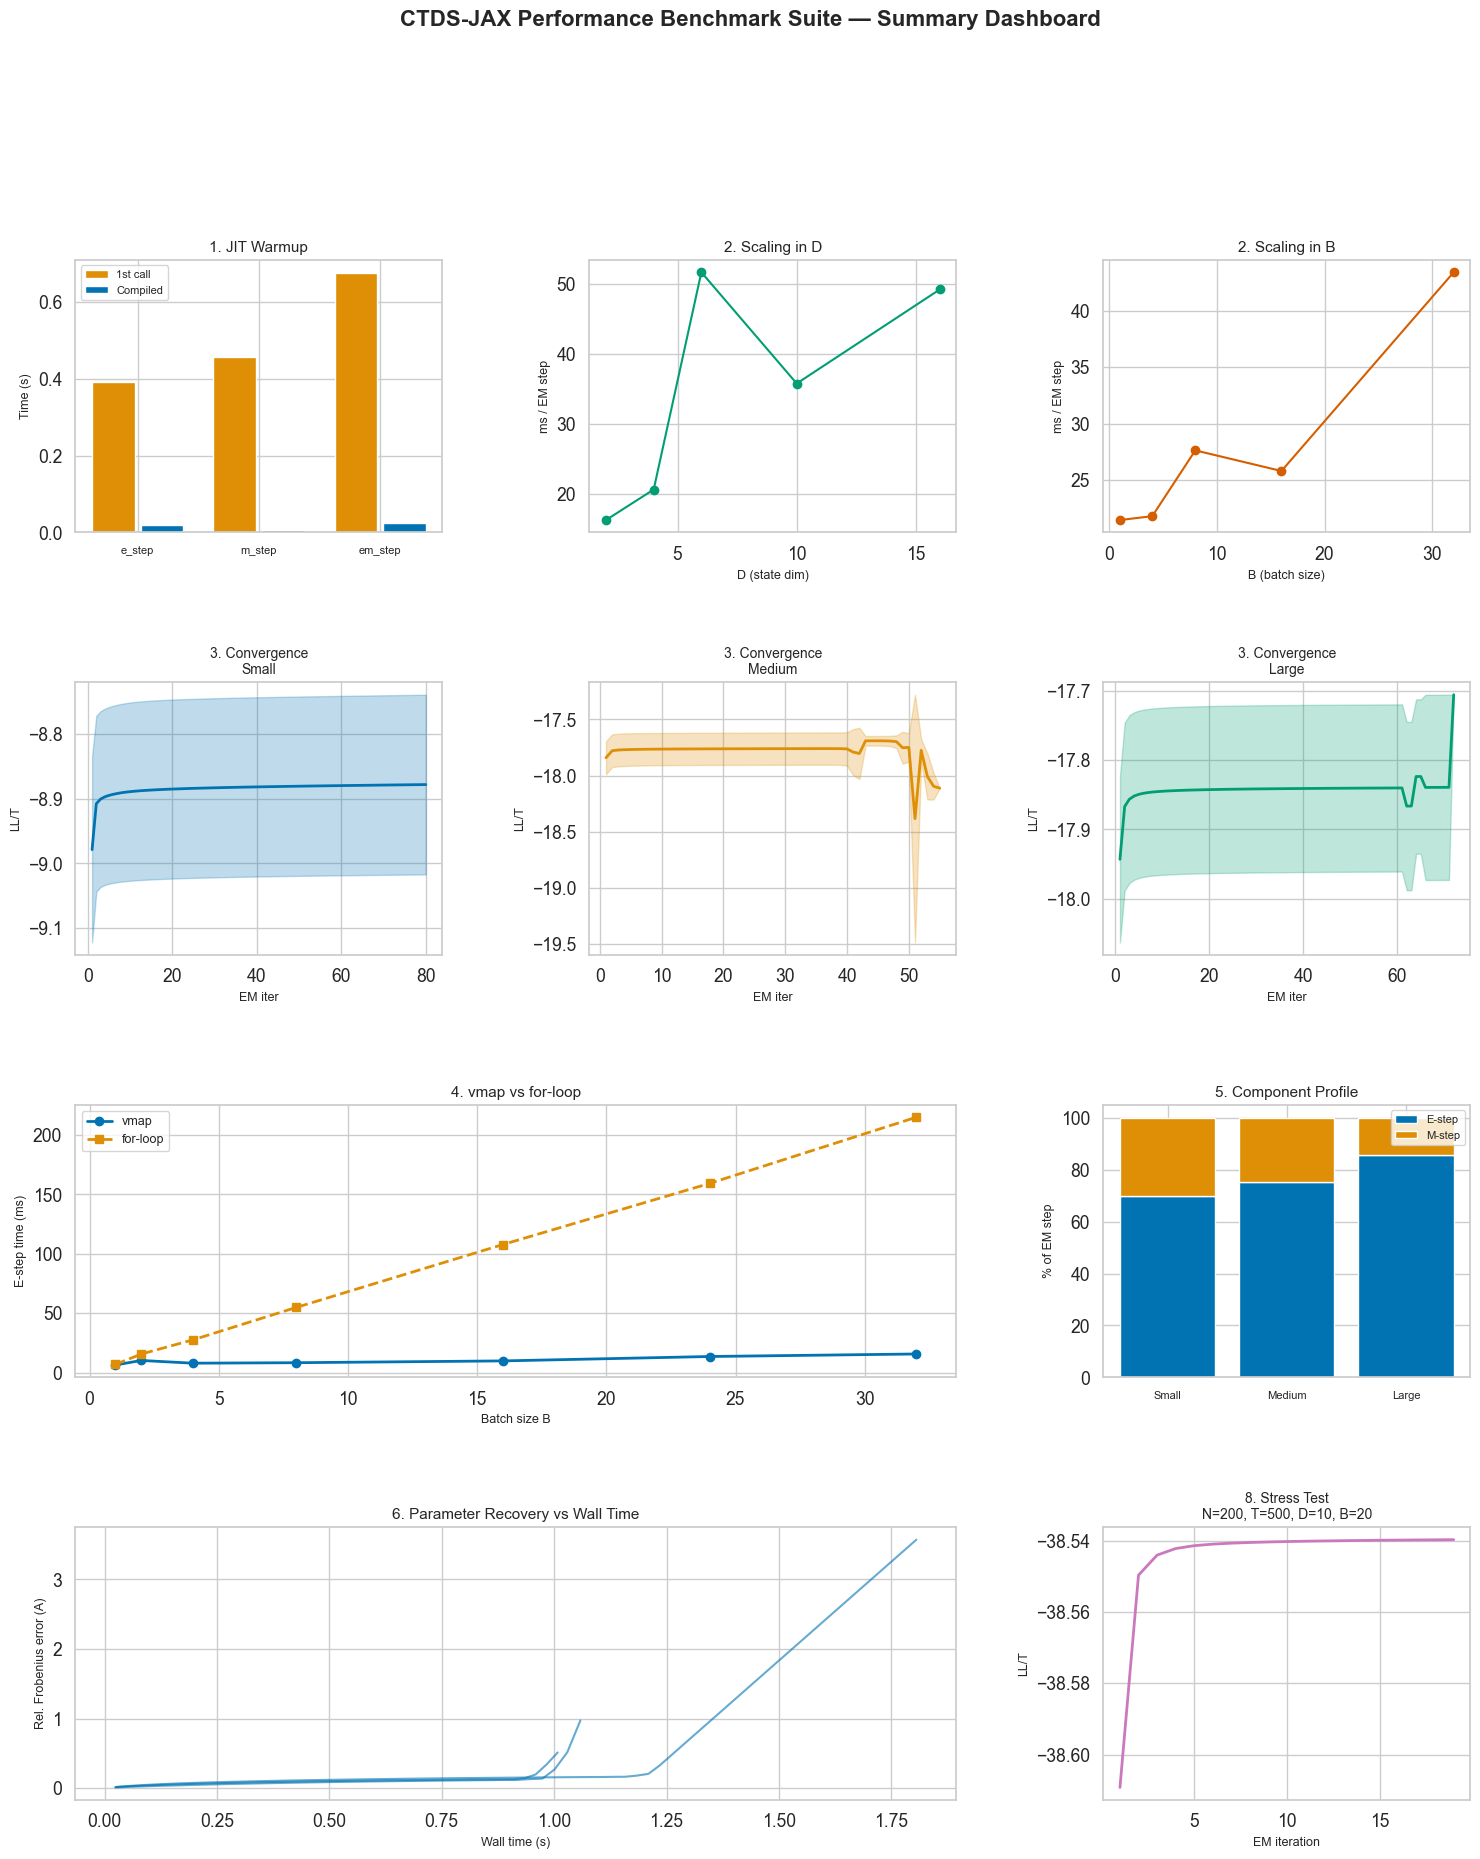

Summary dashboard saved.


In [47]:
fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── Row 0: JIT warmup ───────────────────────────────────────────
ax_jit = fig.add_subplot(gs[0, 0])
x_ = np.arange(len(labels))
ax_jit.bar(x_ - 0.2, compile_, 0.35, label='1st call', color=PALETTE[1])
ax_jit.bar(x_ + 0.2, compiled, 0.35, label='Compiled', color=PALETTE[0])
ax_jit.set_xticks(x_); ax_jit.set_xticklabels(labels, fontsize=8)
ax_jit.set_title('1. JIT Warmup', fontsize=11)
ax_jit.set_ylabel('Time (s)', fontsize=9)
ax_jit.legend(fontsize=8)

# ── Row 0: Scaling in D ─────────────────────────────────────────
ax_scD = fig.add_subplot(gs[0, 1])
xs_D = np.array([r[0] for r in res_D])
ys_D = np.array([r[1]*1000 for r in res_D])
ax_scD.plot(xs_D[~np.isnan(ys_D)], ys_D[~np.isnan(ys_D)], 'o-', color=PALETTE[2])
ax_scD.set_xlabel('D (state dim)', fontsize=9)
ax_scD.set_ylabel('ms / EM step', fontsize=9)
ax_scD.set_title('2. Scaling in D', fontsize=11)

# ── Row 0: Scaling in B ─────────────────────────────────────────
ax_scB = fig.add_subplot(gs[0, 2])
xs_B = np.array([r[0] for r in res_B])
ys_B = np.array([r[1]*1000 for r in res_B])
ax_scB.plot(xs_B[~np.isnan(ys_B)], ys_B[~np.isnan(ys_B)], 'o-', color=PALETTE[3])
ax_scB.set_xlabel('B (batch size)', fontsize=9)
ax_scB.set_ylabel('ms / EM step', fontsize=9)
ax_scB.set_title('2. Scaling in B', fontsize=11)

# ── Row 1: Convergence curves ───────────────────────────────────
for col_idx, (label, data) in enumerate(convergence_results.items()):
    ax_c = fig.add_subplot(gs[1, col_idx])
    curves = data['curves']
    max_len = max(len(c) for c in curves)
    padded  = np.full((len(curves), max_len), np.nan)
    for i, c in enumerate(curves): padded[i, :len(c)] = c
    mean_c = np.nanmean(padded, 0)
    std_c  = np.nanstd(padded, 0)
    iters_ = np.arange(1, max_len+1)
    ax_c.fill_between(iters_, mean_c-std_c, mean_c+std_c, alpha=0.25, color=PALETTE[col_idx])
    ax_c.plot(iters_, mean_c, lw=2, color=PALETTE[col_idx])
    ax_c.set_title(f'3. Convergence\n{label.split("(")[0].strip()}', fontsize=10)
    ax_c.set_xlabel('EM iter', fontsize=9); ax_c.set_ylabel('LL/T', fontsize=9)

# ── Row 2: vmap efficiency & component profiling ────────────────
ax_vmap = fig.add_subplot(gs[2, :2])
ax_vmap.plot(B_VALUES, vmap_m, 'o-', color=PALETTE[0], lw=2, label='vmap')
ax_vmap.plot(B_VALUES, loop_m, 's--', color=PALETTE[1], lw=2, label='for-loop')
ax_vmap.set_xlabel('Batch size B', fontsize=9)
ax_vmap.set_ylabel('E-step time (ms)', fontsize=9)
ax_vmap.set_title('4. vmap vs for-loop', fontsize=11)
ax_vmap.legend(fontsize=9)

ax_prof = fig.add_subplot(gs[2, 2])
x_p = np.arange(len(labels_p))
ax_prof.bar(x_p, e_times/totals*100, color=PALETTE[0], label='E-step')
ax_prof.bar(x_p, m_times/totals*100, bottom=e_times/totals*100, color=PALETTE[1], label='M-step')
ax_prof.set_xticks(x_p); ax_prof.set_xticklabels(labels_p, fontsize=8)
ax_prof.set_title('5. Component Profile', fontsize=11)
ax_prof.set_ylabel('% of EM step', fontsize=9)
ax_prof.legend(fontsize=8)

# ── Row 3: Recovery & stress test ──────────────────────────────
ax_rec = fig.add_subplot(gs[3, :2])
for res in rec_results:
    ax_rec.plot(res['times'], res['A_errs'], alpha=0.6, lw=1.5, color=PALETTE[0])
ax_rec.set_xlabel('Wall time (s)', fontsize=9)
ax_rec.set_ylabel('Rel. Frobenius error (A)', fontsize=9)
ax_rec.set_title('6. Parameter Recovery vs Wall Time', fontsize=11)

ax_stress = fig.add_subplot(gs[3, 2])
ax_stress.plot(np.arange(1, n_iters_ran+1), lp_stress_clean, color=PALETTE[4], lw=2)
ax_stress.set_xlabel('EM iteration', fontsize=9)
ax_stress.set_ylabel('LL/T', fontsize=9)
ax_stress.set_title(f'8. Stress Test\nN={N_STRESS}, T={T_STRESS}, D={D_STRESS}, B={B_STRESS}', fontsize=10)

fig.suptitle('CTDS-JAX Performance Benchmark Suite — Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.005)
plt.savefig('ctds_jax_benchmark_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary dashboard saved.')